Import all requires library and utils

In [12]:
import copy
import json
import random
import time
import math
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from scipy import ndimage
from torch.utils.data import DataLoader, random_split, Subset, Dataset

import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.10.0
0.25.0


Configs class

In [32]:
@dataclass(slots=True)
class Config:
    model_name: str = ""
    data_dir: str = "./data"
    fast_mode: bool = False
    batch_size: int = 32
    n_show: int = 10
    seed: int = 42
    
cfg = Config()
cfg.fast_mode = True
print(cfg.fast_mode)
cfg

True


Config(model_name='', data_dir='./data', fast_mode=True, batch_size=32, n_show=10, seed=42)

Function that fix the seed

In [33]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(cfg.seed)

Define the device and quantity of epochs

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print('device: ', device)

EPOCHS = 4 if cfg.fast_mode else 12
print('Epochs: ', EPOCHS)

RUNS = pd.DataFrame(
    columns=[
        'experiment_id', 
        'task', 
        'dataset', 
        'seed', 
        'model_summary', 
        'optimizer',
        'lr',
        'epochs_trained',
        'best_val_accuracy',
        'test_accuracy',
        'mean_iou',
        'notes',
    ]
)
print(RUNS)

device:  cpu
Epochs:  4
Empty DataFrame
Columns: [experiment_id, task, dataset, seed, model_summary, optimizer, lr, epochs_trained, best_val_accuracy, test_accuracy, notes]
Index: []


Loading dataset CIFAR100

In [16]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

def loading_cifar100_dataset(
        train_transform: torchvision.transforms,
        test_transform: torchvision.transforms,
        data_dir: str = cfg.data_dir,
) -> Tuple[Dataset, Dataset]:
    
    train_dataset = torchvision.datasets.CIFAR100(data_dir, train=True, download=True, transform=train_transform)
    test_dataset = torchvision.datasets.CIFAR100(data_dir, train=False, download=True, transform=test_transform)
    
    return train_dataset, test_dataset

default_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

ds_train, ds_test = loading_cifar100_dataset(
    default_transform,
    default_transform
)

class_names = ds_train.classes
print("len(class_names): ", len(class_names))
print("test len: ", len(ds_test))
print('Classes', class_names)

len(class_names):  100
test len:  10000
Classes ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip

Create function which separate train on train and val datasets

In [17]:
def make_loaders(
    ds_train: torch.utils.data.Dataset,
    ds_test: torch.utils.data.Dataset,
    seed: int = cfg.seed,
    fast_mode: bool = cfg.fast_mode,
    batch_size: int = cfg.batch_size,
    val_ratio: float = 0.2
):
    train_len = len(ds_train)
    val_len = int(train_len * val_ratio)
    train_len = train_len - val_len
    
    ds_train, ds_val = random_split(
        ds_train, 
        lengths=[train_len, val_len], 
        generator=torch.Generator().manual_seed(seed)
    )
    
    # Fast-mode
    if fast_mode:
        rng = np.random.RandomState(cfg.seed)
        
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)
        
        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test
        
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(
    ds_train,
    ds_test,
)

batch = next(iter(train_loader))
x, y = batch
print("x: ", x.shape, x.dtype)
print("y: ", y.shape, y.dtype)

/Users/mazxal/PycharmProjects/AI-Mirea-Course/homeworks/HW03/eda-cli/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


x:  torch.Size([32, 3, 32, 32]) torch.float32
y:  torch.Size([32]) torch.int64


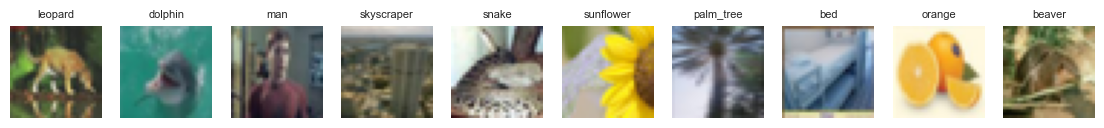

In [18]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10, path_save: str = "") -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]
    
    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
        
    if path_save:
        plt.savefig(path_save)
    plt.show()
    
show_images(train_loader, n=cfg.n_show)

In [19]:
class CNNSimple(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 32 x 32 -> 32 x 32
            nn.ReLU(),
            nn.MaxPool2d(2), # 32 x 32 -> 16 x 16
        
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16 x 16 -> 16 x 16
            nn.ReLU(),
            nn.MaxPool2d(2), # 16 x 16 -> 8 x 8
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 8 x 8 -> 8 x 8
            nn.ReLU(),
            nn.MaxPool2d(2), # 8 x 8 -> 4 x 4
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x
        
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_simple = CNNSimple(num_classes=len(class_names)).to(device=device)
print(cnn_simple)
print("Quantity of model's parameters: ", count_params(cnn_simple))

CNNSimple(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=100, bias=True)
  )
)
Quantity of model's parameters:  643492


Definite the main function like fit, evaluate, train_one_epoch and etc

In [36]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor):
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(
        loader: DataLoader,
        model: nn.Module,
        optimizer: optim,
        criterion: nn.Module,
) -> Tuple[float, float]:
    model.train()
    
    total_loss, total_correct, total_seen = 0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        preds = model(x)
        loss = criterion(preds, y)
        
        if not torch.isfinite(loss):
            return float("nan"), float("nan")
        
        loss.backward()
        optimizer.step()
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(preds, dim=1) == y).sum().item()
        total_seen += bs
        
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> Tuple[float, float] :
    model.eval()
    total_loss, total_accuracy, total_seen = 0, 0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        
        preds = model(x)
        loss = criterion(preds, y)
        
        if not torch.isfinite(loss):
            return float('nan'), float('nan')
        
        bs = y.size(0)
        
        total_loss += (loss.item() * bs)
        total_accuracy += (torch.argmax(preds, dim=1) == y).sum().item()
        total_seen += bs
        
    return total_loss / total_seen, total_accuracy / total_seen

def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: nn.Module,
    criterion: nn.Module,
    epochs: int = 4,
    verbose: bool = True,    
) -> Dict:
    
    history = {
        "train_acc": [],
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
    }
    
    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(
            train_loader,
            model,
            optimizer,
            criterion,
        )
        
        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
        )
        
        dt = time.time() - t0
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        if verbose:
            print(
                f"Epochs: {epoch + 1:02d}/{epochs:02d}, time: {dt:.1f}s | "
                f"Train Loss: {train_loss:.4f}, train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, val Acc: {val_acc:.4f}"
            )
        
        if not math.isfinite(train_loss) or (not math.isfinite(val_loss)):
            print("NaN/Inf in loss - feature of problems with LR/stability. Stop fitting.")
            break
        
    return history

def plot_history(history: Dict[str, List[float]], title: str = "", save_dir: str = "") -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(10, 8))
    plt.plot(epochs, history["train_loss"], label="train loss")
    plt.plot(epochs, history["val_loss"], label="val loss")
    plt.title(title + " Training Loss")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(False)    
    plt.show()
    
    plt.figure(figsize=(10, 8))
    plt.plot(epochs, history['train_acc'], label="train accuracy")
    plt.plot(epochs, history['val_acc'], label="val accuracy")
    plt.title(title + " Training Accuracy")
    plt.xlabel("epochs")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(False)
    plt.show()
    
def plot_best_history(
    history: Dict[str, List[float]],
    title: str = "",
    save_path: str | None = None,
) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    axes[0].plot(epochs, history["train_loss"], label="train loss")
    axes[0].plot(epochs, history["val_loss"], label="val loss")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("epochs")
    axes[0].set_ylabel("loss")
    axes[0].legend()
    axes[0].grid(False)

    axes[1].plot(epochs, history["train_acc"], label="train accuracy")
    axes[1].plot(epochs, history["val_acc"], label="val accuracy")
    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("epochs")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    axes[1].grid(False)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)
    
def run_experiment(
        experiment_id: str,
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        criterion: nn.Module,
        dataset: str,
        model_name: str,
        notes: Optional[str] = None,
        lr: float = 1e-3,
        weight_decay: float = 0.0,
        epochs: int = EPOCHS,
) -> Dict[str, Any]:
    
    model.to(device)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=lr, 
        weight_decay=weight_decay
    )
    
    print("\n" + "=" * 80)
    print(f"Experiment {experiment_id} | lr={lr}, weight_decay={weight_decay}, epochs={epochs}")
    print("Trainable parameters:", count_params(model))
    
    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs)
    best_val_acc = float(np.nanmax(hist['val_acc'])) if len(hist['val_acc']) else float("nan")
    
    return {
        "experiment_id": experiment_id,
        "model": model,
        "best_val_accuracy": best_val_acc,
        "history": hist,
        "optimizer": "Adam",
        "lr": lr,
        "epochs_trained": epochs,
        "dataset": dataset,
        "model_summary": model_name,
        "notes": notes,
    }

def save_to_runs(
        experiment_run: Dict,
        runs: pd.DataFrame,
    # experiment_id: str,
    # task: str,
    #     dataset: str,
    #     seed: int,
    #     model_summary: str,
    #     optimizer: str,
    #     lr: float,
    #     epochs_trained: int,
    #     best_val_accuracy: float,
    #     test_accuracy: float,
    #     notes: str,
) -> pd.DataFrame:
    
    drop_fields = ["model", "history"]
    
    filtered_run = {k: v for k, v in experiment_run.items() if k not in drop_fields}
    
    experiment_run = pd.DataFrame([filtered_run])
    return pd.concat([runs, experiment_run], ignore_index=True)
    
def save_runs(
        runs: pd.DataFrame,
        path: str,
):
    runs.to_csv(path, index=False)
    
def save_json(data: dict, path: str) -> None:
    if not path.endswith(".json"):
        raise ValueError("must be .json")

    with open(path, "w") as f:
        json.dump(data, f, indent=4)
    

In [21]:
criterion = nn.CrossEntropyLoss()

In [37]:
res_c1 = run_experiment(
    "C1",
    cnn_simple,
    train_loader,
    val_loader,
    criterion,
    dataset='cifar100',
    model_name="simple_cnn",
)
plot_history(res_c1["history"], title="Simple CNN")


Experiment C1 | lr=0.001, weight_decay=0.0, epochs=4
Trainable parameters: 643492


KeyboardInterrupt: 

In [31]:
ds_train_aug, ds_test = loading_cifar100_dataset(
    train_transform=torchvision.transforms.Compose([
        torchvision.transforms.RandomCrop(32, padding=4),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        torchvision.transforms.RandomRotation(10),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
        torchvision.transforms.RandomErasing(p=0.1),
]),
    test_transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ])
)

train_loader_aug, val_loader_aug, _ = make_loaders(
    ds_train_aug,
    ds_test,
)

cnn_simple_aug = CNNSimple(num_classes=len(class_names)).to(device=device)
res_c2 = run_experiment(
    "C2", 
    cnn_simple_aug, 
    train_loader_aug, 
    val_loader_aug, 
    criterion, 
    dataset='cifar100',
    model_name="simple_cnn",
    notes="with augmentation",
    lr=1e-4
)

plot_history(res_c2["history"], title="Simple CNN with augmentation")


Experiment C2 | lr=0.0001, weight_decay=0.0, epochs=12
Trainable parameters: 643492
Epochs: 01/12, time: 80.0s | Train Loss: 4.2213, train Acc: 0.0600 | Val Loss: 3.9742, val Acc: 0.0992
Epochs: 02/12, time: 86.0s | Train Loss: 3.8482, train Acc: 0.1135 | Val Loss: 3.7231, val Acc: 0.1343
Epochs: 03/12, time: 75.6s | Train Loss: 3.6591, train Acc: 0.1445 | Val Loss: 3.5844, val Acc: 0.1582
Epochs: 04/12, time: 109.1s | Train Loss: 3.5263, train Acc: 0.1662 | Val Loss: 3.4825, val Acc: 0.1761
Epochs: 05/12, time: 70.8s | Train Loss: 3.4211, train Acc: 0.1850 | Val Loss: 3.4085, val Acc: 0.1919
Epochs: 06/12, time: 66.6s | Train Loss: 3.3438, train Acc: 0.1964 | Val Loss: 3.3270, val Acc: 0.2060


KeyboardInterrupt: 

Files already downloaded and verified
Files already downloaded and verified

Experiment C3 | lr=0.001, weight_decay=0.0, epochs=12
Trainable parameters: 51300
Epochs: 01/12, time: 32.6s | Train Loss: 3.6867, train Acc: 0.1688 | Val Loss: 3.3439, val Acc: 0.2344
Epochs: 02/12, time: 32.0s | Train Loss: 3.3210, train Acc: 0.2238 | Val Loss: 3.3694, val Acc: 0.2338
Epochs: 03/12, time: 30.0s | Train Loss: 3.2570, train Acc: 0.2334 | Val Loss: 3.3432, val Acc: 0.2338
Epochs: 04/12, time: 31.1s | Train Loss: 3.2165, train Acc: 0.2417 | Val Loss: 3.3606, val Acc: 0.2436
Epochs: 05/12, time: 29.7s | Train Loss: 3.1978, train Acc: 0.2420 | Val Loss: 3.3133, val Acc: 0.2407
Epochs: 06/12, time: 29.0s | Train Loss: 3.1722, train Acc: 0.2470 | Val Loss: 3.3581, val Acc: 0.2416
Epochs: 07/12, time: 29.1s | Train Loss: 3.1731, train Acc: 0.2497 | Val Loss: 3.3483, val Acc: 0.2451
Epochs: 08/12, time: 28.5s | Train Loss: 3.1618, train Acc: 0.2515 | Val Loss: 3.3221, val Acc: 0.2539
Epochs: 09/12, ti

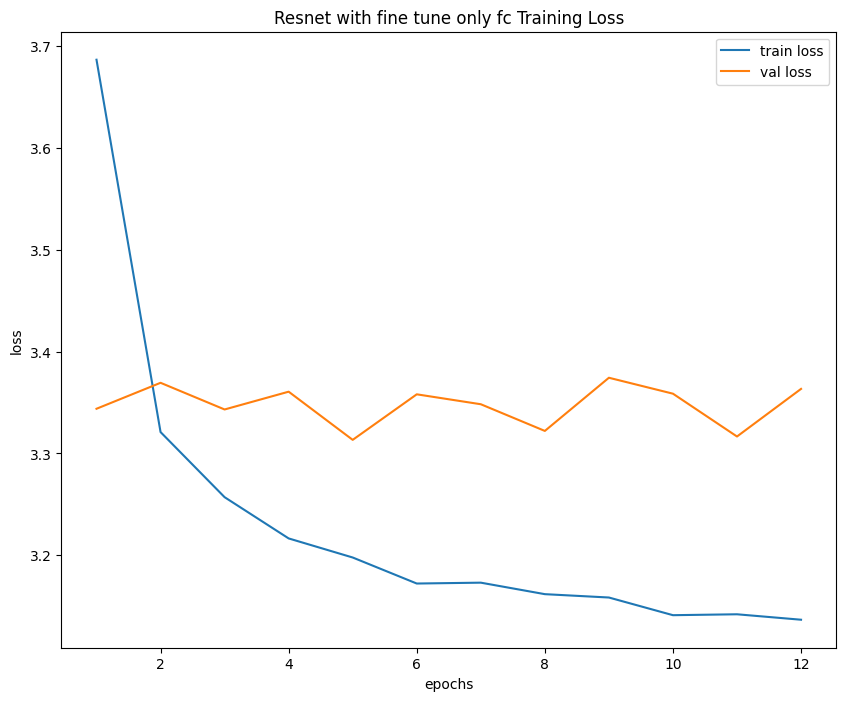

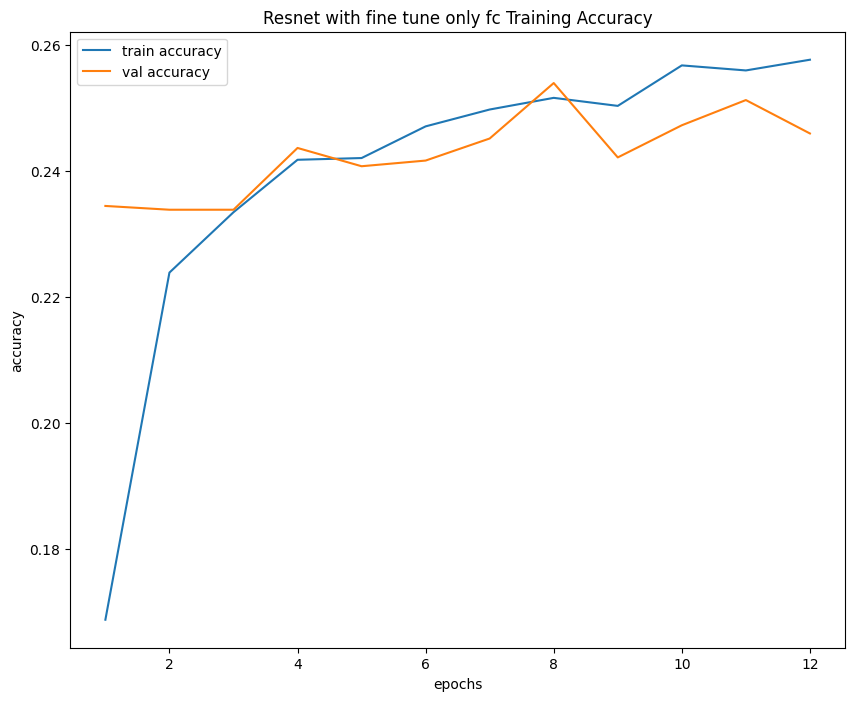

In [41]:
ds_train_for_resnet, ds_test_for_resnet = loading_cifar100_dataset(
    train_transform=torchvision.transforms.Compose([
        torchvision.transforms.Resize((224, 224)),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ]),
    test_transform=torchvision.transforms.Compose([
        torchvision.transforms.Resize((224, 224)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
    ])
)

train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders(
    ds_train_for_resnet,
    ds_test_for_resnet,
)

model_c3 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT).to(device=device)
model_c3.fc = torch.nn.Linear(in_features=model_c3.fc.in_features, out_features=len(class_names))

model_c3.requires_grad_(False)
model_c3.fc.requires_grad_(True)

res_c3 = run_experiment(
    "C3", 
    model_c3, 
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    dataset='cifar100',
    model_name="resnet_18",
    notes="with finetune only fc",
)

plot_history(res_c3["history"], title="Resnet with fine tune only fc")


Experiment C4 | lr=0.001, weight_decay=0.0, epochs=12
Trainable parameters: 8445028
Epochs: 01/12, time: 70.5s | Train Loss: 1.8859, train Acc: 0.4810 | Val Loss: 1.4523, val Acc: 0.5881
Epochs: 02/12, time: 67.8s | Train Loss: 1.2159, train Acc: 0.6438 | Val Loss: 1.2672, val Acc: 0.6417
Epochs: 03/12, time: 68.2s | Train Loss: 0.9388, train Acc: 0.7195 | Val Loss: 1.2405, val Acc: 0.6555
Epochs: 04/12, time: 69.0s | Train Loss: 0.7361, train Acc: 0.7738 | Val Loss: 1.2043, val Acc: 0.6760
Epochs: 05/12, time: 68.8s | Train Loss: 0.5612, train Acc: 0.8255 | Val Loss: 1.3027, val Acc: 0.6691
Epochs: 06/12, time: 68.8s | Train Loss: 0.4526, train Acc: 0.8579 | Val Loss: 1.2689, val Acc: 0.6848
Epochs: 07/12, time: 69.3s | Train Loss: 0.3474, train Acc: 0.8883 | Val Loss: 1.4317, val Acc: 0.6678
Epochs: 08/12, time: 70.0s | Train Loss: 0.3002, train Acc: 0.9054 | Val Loss: 1.4330, val Acc: 0.6867
Epochs: 09/12, time: 69.6s | Train Loss: 0.2509, train Acc: 0.9210 | Val Loss: 1.4877, val 

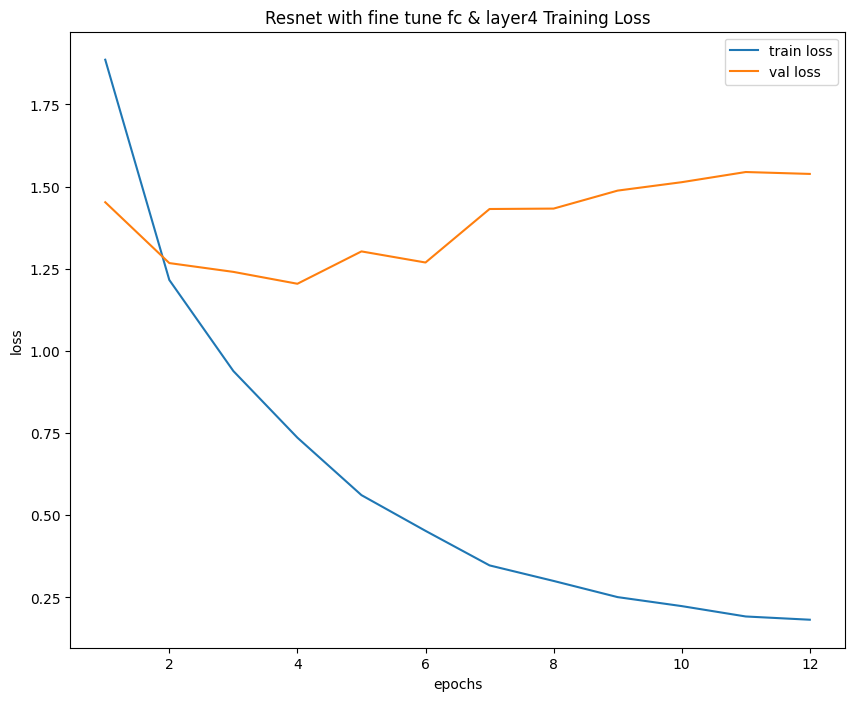

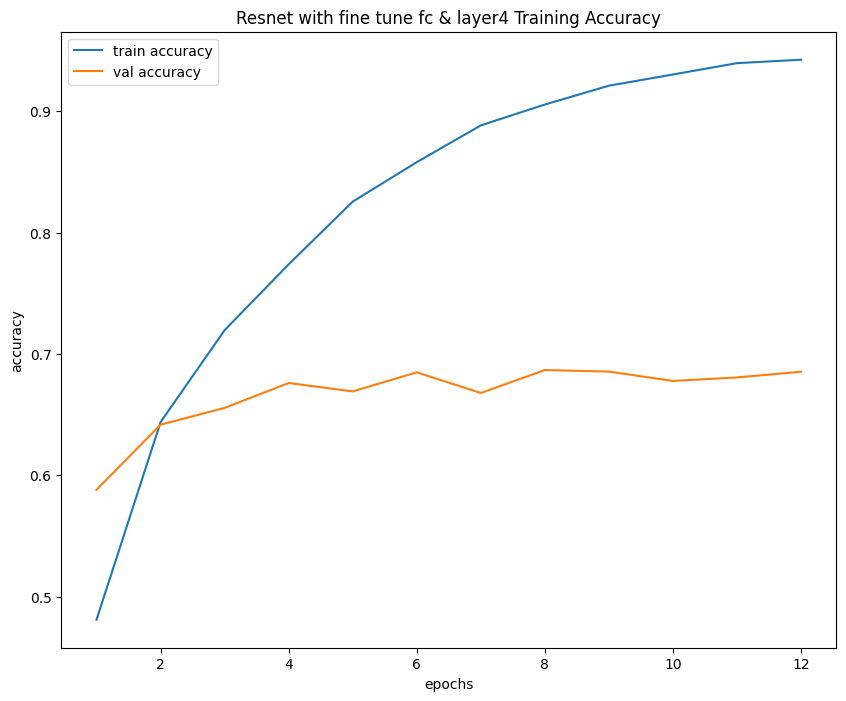

In [42]:
model_c4 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT).to(device=device)
model_c4.fc = torch.nn.Linear(in_features=model_c4.fc.in_features, out_features=len(class_names))

model_c4.requires_grad_(False)
model_c4.layer4.requires_grad_(True)
model_c4.fc.requires_grad_(True)

res_c4 = run_experiment(
    "C4",
    model_c4,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    dataset='cifar100',
    model_name="resnet_18",
    notes="with finetune fc and layer4",
)

plot_history(res_c4['history'], title="Resnet with fine tune fc & layer4")

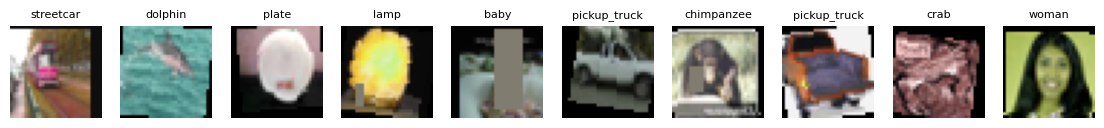

In [43]:
show_images(train_loader_aug, n=10, path_save="./artifacts/figures/augmentations_preview.png")

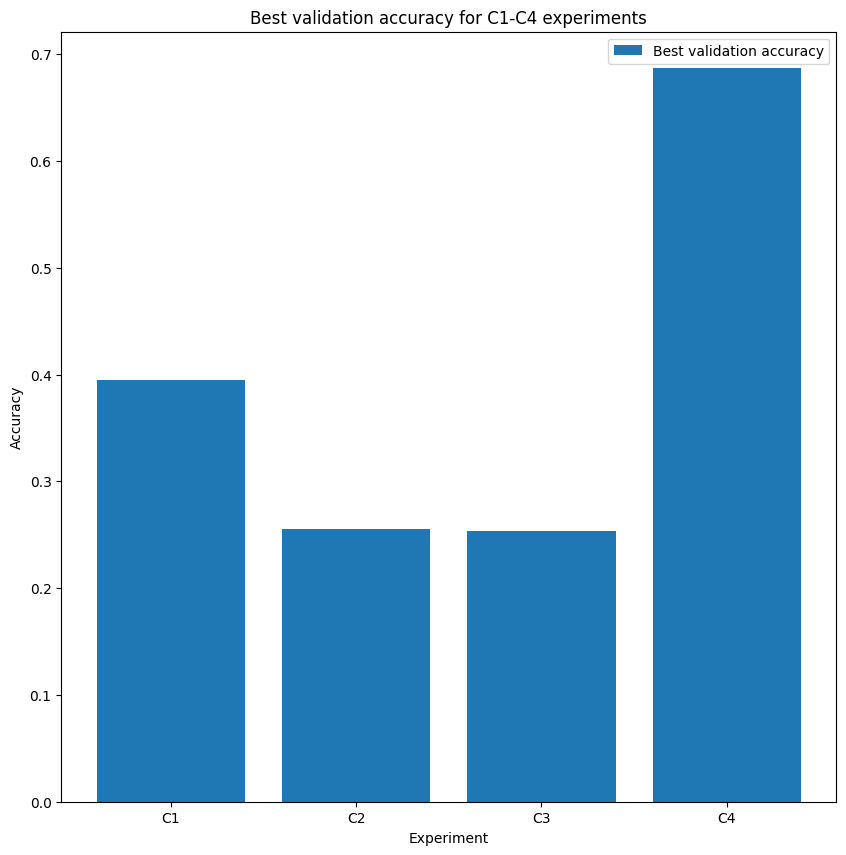

In [49]:
best_val_acc = [res_c1['best_val_accuracy'], res_c2['best_val_accuracy'], res_c3['best_val_accuracy'], res_c4['best_val_accuracy']]
experiment_names = ["C1", "C2", "C3", "C4"]

plt.figure(figsize=(10, 10))
plt.bar(experiment_names, best_val_acc, label="Best validation accuracy")
plt.title("Best validation accuracy for C1-C4 experiments")
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(False)
plt.savefig("./artifacts/figures/classification_compare.png")
plt.show()

In [60]:
res_c1['test_accuracy'] = 0.0
res_c2['test_accuracy'] = 0.0
res_c3['test_accuracy'] = 0.0

test_loss, test_acc = evaluate(model_c4, test_loader_resnet, criterion)

res_c4['test_accuracy'] = test_acc

res_c1['seed'], res_c2['seed'], res_c3['seed'], res_c4['seed'] = [42] * 4
res_c1['task'], res_c2['task'], res_c3['task'], res_c4['task'] = ['classification'] * 4

In [59]:
res_c1

{'experiment_id': 'C1',
 'model': CNNSimple(
   (features): Sequential(
     (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (4): ReLU()
     (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (7): ReLU()
     (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=2048, out_features=256, bias=True)
     (2): ReLU()
     (3): Linear(in_features=256, out_features=100, bias=True)
   )
 ),
 'best_val_acc': 0.3946,
 'history': {'train_acc': [0.14285,
   0.28265,
   0.36555,
   0.429475,
   0.4767,
   0.525175,
   0.570275,
   0.609025,
   0.64415,
   0

In [64]:
RUNS = save_to_runs(res_c1, RUNS)
RUNS = save_to_runs(res_c2, RUNS)
RUNS = save_to_runs(res_c3, RUNS)
RUNS = save_to_runs(res_c4, RUNS)

In [65]:
RUNS

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,notes,best_val_acc,test_acc
0,C1,classification,cifar100,42,simple_cnn,Adam,0.0010,12,NaN,0.0000,None,0.3946,0.0000
1,C2,classification,cifar100,42,simple_cnn,Adam,0.0001,12,NaN,0.0000,with augmentation,0.2555,0.0000
2,C3,classification,cifar100,42,resnet_18,Adam,0.0010,12,NaN,0.0000,with finetune only fc,0.2539,0.0000
3,C4,classification,cifar100,42,resnet_18,Adam,0.0010,12,NaN,0.6872,with finetune fc and layer4,0.6867,0.6872
4,C1,classification,cifar100,42,simple_cnn,Adam,0.0010,12,NaN,0.0000,None,0.3946,0.0000
5,C2,classification,cifar100,42,simple_cnn,Adam,0.0001,12,NaN,0.0000,with augmentation,0.2555,0.0000
6,C3,classification,cifar100,42,resnet_18,Adam,0.0010,12,NaN,0.0000,with finetune only fc,0.2539,0.0000
7,C4,classification,cifar100,42,resnet_18,Adam,0.0010,12,NaN,0.6872,with finetune fc and layer4,0.6867,0.6872


In [67]:
save_runs(RUNS, './artifacts/runs.csv')

In [68]:
torch.save(model_c4.state_dict(), './artifacts/best_classifier.pt')

In [81]:
best_res = copy.deepcopy(res_c4)
best_res['transformers'] = {
    "resize": 224,
    "normalize": True,
    "to_tensor": True
}

filter_fields = [
    'task', 'model', 'test_accuracy', 'history', 'best_val_accuracy',
]
[best_res.pop(x, None) for x in filter_fields]

save_json(best_res, './artifacts/best_classifier_config.json')

In [85]:
res_c4

{'experiment_id': 'C4',
 'best_val_acc': 0.6867,
 'optimizer': 'Adam',
 'lr': 0.001,
 'epochs_trained': 12,
 'dataset': 'cifar100',
 'model_summary': 'resnet_18',
 'notes': 'with finetune fc and layer4',
 'test_acc': 0.6872,
 'seed': 42,
 'transformers': {'resize': 224, 'normalize': True, 'to_tensor': True}}

In [84]:
plot_best_history(
    res_c4["history"],
    title="ResNet18 fine-tune fc & layer4",
    save_path="figures/classification_curves_best.png",
)

KeyError: 'history'

# Here starts second part of homework (part-B)

In [38]:
import torchvision.transforms as T
from torchvision.datasets import VOCSegmentation 
from torchvision.models.segmentation import fcn_resnet50

In [41]:
dataset = VOCSegmentation(
    root='./data',
    year='2012',
    image_set='train',
    download=True,
    transform=T.ToTensor(),
    target_transform=None,
)

img, mask = dataset[0]

In [42]:
print("image shape: ", img.shape)
mask_np = np.array(mask)
print("mask shape: ", mask_np.shape)
print("mask: ", np.unique(mask_np))

image shape:  torch.Size([3, 281, 500])
mask shape:  (281, 500)
mask:  [  0   1  15 255]


In [43]:
model = fcn_resnet50(weights=torchvision.models.segmentation.FCN_ResNet50_Weights.DEFAULT)
model.eval()

Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /Users/mazxal/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100.0%


FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

In [44]:
batch_img = img.unsqueeze(0)
with torch.no_grad():
    out = model(batch_img)
    print("out shape: ", out['out'].shape)
    predicted_mask = torch.argmax(out['out'], dim=1)
    print(predicted_mask.shape)
    print(np.unique(predicted_mask.cpu().numpy()))
    predicted_mask = predicted_mask.squeeze(0)

out shape:  torch.Size([1, 21, 281, 500])
torch.Size([1, 281, 500])
[ 0  1 15]


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x1108d93a0>
Traceback (most recent call last):
  File "/Users/mazxal/PycharmProjects/AI-Mirea-Course/homeworks/HW03/eda-cli/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/Users/mazxal/PycharmProjects/AI-Mirea-Course/homeworks/HW03/eda-cli/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1665, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


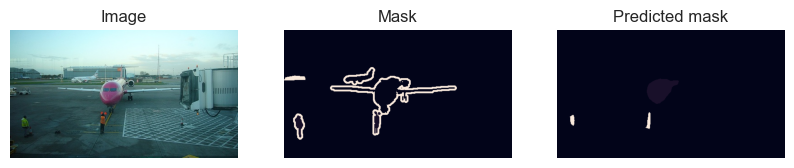

In [45]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_np)
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask)
plt.title("Predicted mask")
plt.axis('off')

plt.savefig('./artifacts/figures/segmentation_examples.png')
plt.show()

In [46]:
def make_gt_fg_and_valid(mask):
    if not torch.is_tensor(mask):
        mask = torch.from_numpy(np.array(mask))
    else:
        mask = mask.clone()
        
    valid_mask = mask != 255
    gt_fg_mask = (mask != 0) & valid_mask
    return gt_fg_mask.bool(), valid_mask.bool()

def make_v1_mask(predict):
    
    if predict.ndim == 3 and predict.shape[0] == 1:
        predict = predict.squeeze(0)
        
    pred_fg_v1 = predict != 0
    return pred_fg_v1.bool()

def remove_small_components(binary_mask, min_size=500):
    labeled, num_futures = ndimage.label(binary_mask)
    result = np.zeros_like(binary_mask, dtype=bool)
    
    for label_id in range(1, num_futures + 1):
        component = labeled == label_id
        if component.sum() >= min_size:
            result |= component
            
    return result

def make_v2_mask(predict, min_size=500):
    pred_fg_v1 = make_v1_mask(predict)
    pred_fg_v1_np = pred_fg_v1.cpu().numpy().astype(bool)
    pred_fg_v2_np = remove_small_components(pred_fg_v1_np, min_size=min_size)
    pred_fg_v2 = torch.from_numpy(pred_fg_v2_np)
    
    return pred_fg_v2.bool()

def compute_iou(pred_fg_mask, gt_fg_mask, valid_mask):
    pred_valid = pred_fg_mask[valid_mask]
    gt_valid = gt_fg_mask[valid_mask]
    
    intersection = (pred_valid & gt_valid).sum().item()
    union = (pred_valid | gt_valid).sum().item()
    
    if union == 0:
        return 1.0
    
    return intersection / union

def evaluate_sample(img, mask, model, device=device, min_size=500):
    model.eval()
    
    batch_img = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(batch_img)
        predicted_mask = torch.argmax(out['out'], dim=1).squeeze(0).cpu()
        
    gt_fg_mask, valid_mask = make_gt_fg_and_valid(mask)
    
    pred_fg_v1 = make_v1_mask(predicted_mask)
    pred_fg_v2 = make_v2_mask(predicted_mask, min_size=min_size)
    
    iou_v1 = compute_iou(pred_fg_v1, gt_fg_mask, valid_mask)
    iou_v2 = compute_iou(pred_fg_v2, gt_fg_mask, valid_mask)
    
    return {
        'predicted_mask': predicted_mask,
        'gt_fg_mask': gt_fg_mask,
        'valid_mask': valid_mask,
        'pred_fg_v1': pred_fg_v1,
        'pred_fg_v2': pred_fg_v2,
        'iou_v1': iou_v1,
        'iou_v2': iou_v2
    }

In [47]:
sample_result = evaluate_sample(img, mask, model, device=device, min_size=500)
print("IoU V1:", sample_result["iou_v1"])
print("IoU V2:", sample_result["iou_v2"])
print("GT unique:", torch.unique(sample_result["gt_fg_mask"]))
print("Pred V1 unique:", torch.unique(sample_result["pred_fg_v1"]))
print("Pred V2 unique:", torch.unique(sample_result["pred_fg_v2"]))

IoU V1: 0.4641071428571429
IoU V2: 0.4014285714285714
GT unique: tensor([False,  True])
Pred V1 unique: tensor([False,  True])
Pred V2 unique: tensor([False,  True])


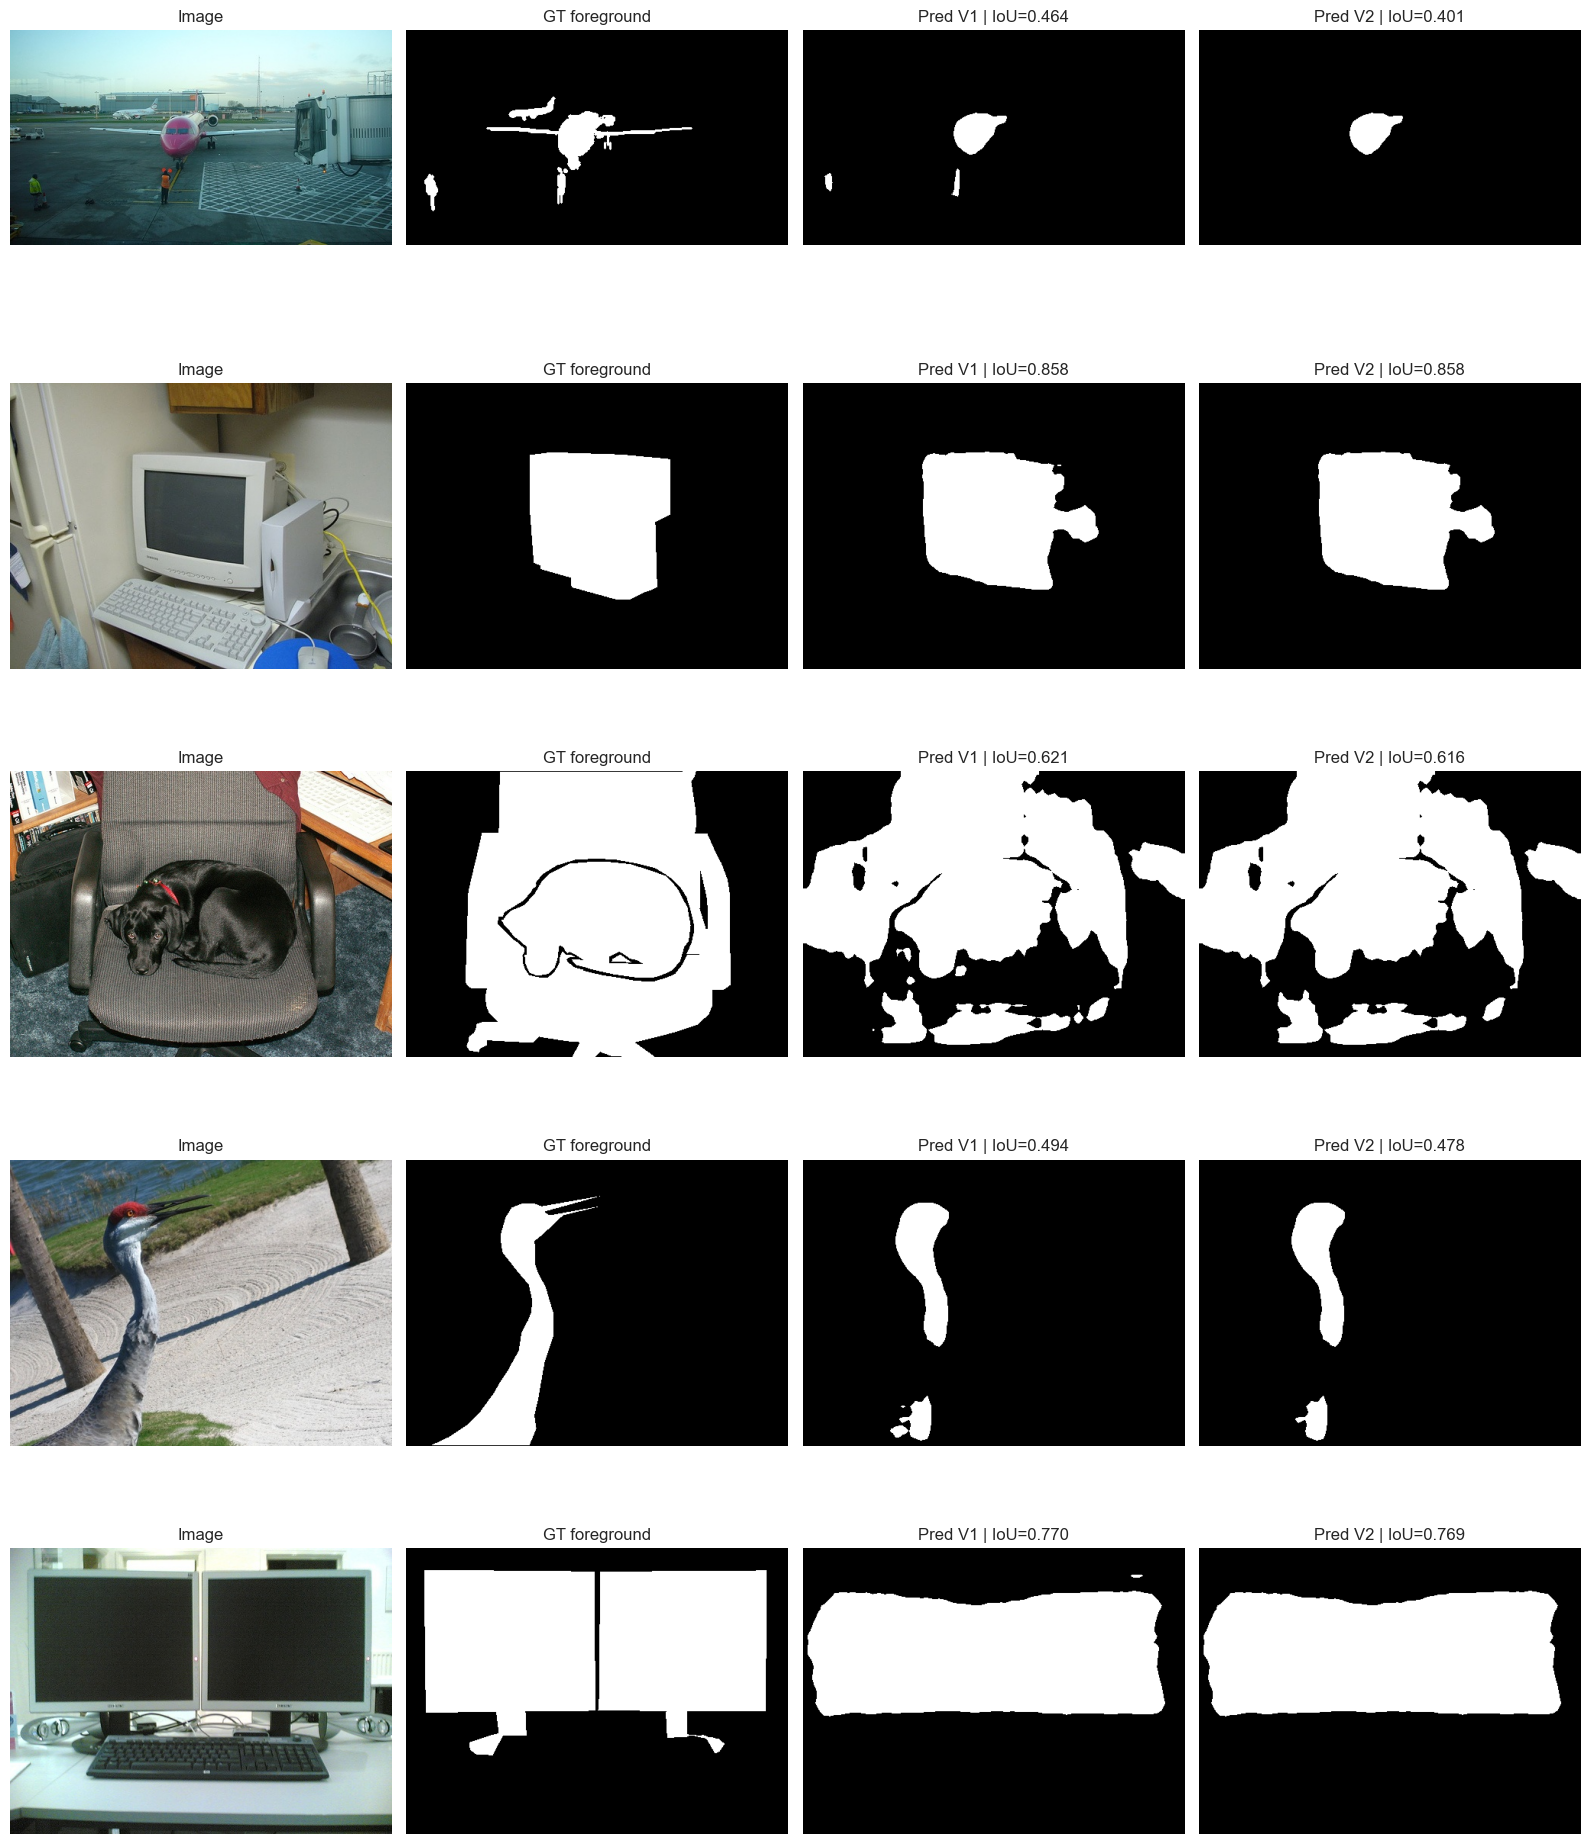

In [56]:
num_examples = 5

fig, axes = plt.subplots(num_examples, 4, figsize=(16, 4 * num_examples))

for i in range(num_examples):
    img_i, mask_i = dataset[i]
    sample_result = evaluate_sample(img_i, mask_i, model, device=device, min_size=500)

    axes[i, 0].imshow(img_i.permute(1, 2, 0))
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sample_result["gt_fg_mask"].cpu().numpy(), cmap="gray")
    axes[i, 1].set_title("GT foreground")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(sample_result["pred_fg_v1"].cpu().numpy(), cmap="gray")
    axes[i, 2].set_title(f"Pred V1 | IoU={sample_result['iou_v1']:.3f}")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(sample_result["pred_fg_v2"].cpu().numpy(), cmap="gray")
    axes[i, 3].set_title(f"Pred V2 | IoU={sample_result['iou_v2']:.3f}")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.savefig("./artifacts/figures/segmentation_examples.png")
plt.show()

In [49]:
results = []
num_samples = 20

for i in range(num_samples):
    img_i, mask_i = dataset[i]
    res = evaluate_sample(img_i, mask_i, model, device=device, min_size=500)

    results.append({
        "index": i,
        "iou_v1": res["iou_v1"],
        "iou_v2": res["iou_v2"],
    })

mean_iou_v1 = np.mean([r["iou_v1"] for r in results])
mean_iou_v2 = np.mean([r["iou_v2"] for r in results])

print("Mean iou v1: ", mean_iou_v1)
print("Mean iou v2: ", mean_iou_v2)

Mean iou v1:  0.7346707596590815
Mean iou v2:  0.728504311529315


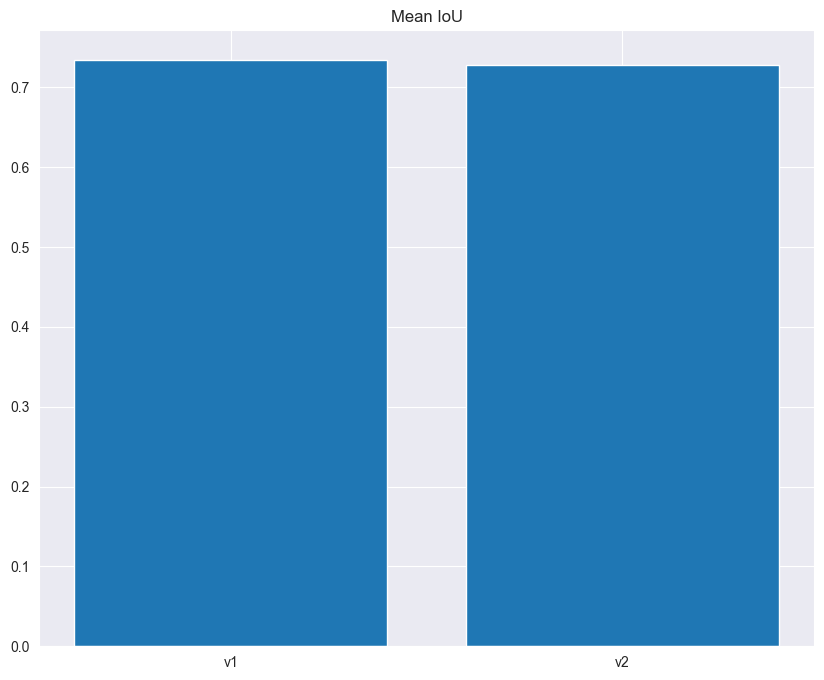

In [51]:
plt.figure(figsize=(10, 8))
plt.bar(['v1', 'v2'], [mean_iou_v1, mean_iou_v2], align='center')
plt.title("Mean IoU")
plt.savefig('./artifacts/figures/segmentation_metrics.png')
plt.show()

In [55]:
RUNS = save_to_runs({
    "experiment_id": "V1",
    "task": "segmentation",
    "seed": cfg.seed,
    "test_accuracy": 0,
    "model": model,
    "best_val_accuracy": 0,
    "optimizer": "",
    "lr": 0,
    "epochs_trained": 0,
    "dataset": "VOCSegmentation",
    "model_summary": "fcn_resnet50",
    "notes": "",
    "mean_iou": mean_iou_v1,
}, RUNS)

RUNS = save_to_runs({
    "experiment_id": "V2",
    "task": "segmentation",
    "seed": cfg.seed,
    "test_accuracy": 0,
    "model": model,
    "best_val_accuracy": 0,
    "optimizer": "",
    "lr": 0,
    "epochs_trained": 0,
    "dataset": "VOCSegmentation",
    "model_summary": "fcn_resnet50",
    "notes": "",
    "mean_iou": mean_iou_v2,
}, RUNS)

save_runs(RUNS, './artifacts/runs.csv')